
  BITCOIN (BTC) vs DAX INDEX (GERMANY) — IMPACT ANALYSIS

  Detected files:
    DAX Index : /content/DAX Historical Data.csv
    Bitcoin   : ./Bitcoin Historical Data_crypto.csv

  Data loaded: 87 overlapping trading days (weekends dropped)
  Period : Jan 2019 → Mar 2026

      Date  BTC_Return  DAX_Return
2019-01-01     -0.0734      0.0582
2019-02-01      0.1104      0.0307
2019-03-01      0.0749      0.0009
2019-04-01      0.2970      0.0710
2019-05-01      0.6085     -0.0500
  ...

  SECTION 2 — DESCRIPTIVE STATISTICS
            Count    Mean     Std     Min     25%     50%     75%     Max
BTC_Return   87.0  0.0503  0.1894 -0.3732 -0.0714  0.0246  0.1376  0.6085
DAX_Return   87.0  0.0101  0.0502 -0.1644 -0.0170  0.0150  0.0342  0.1501

  Pearson Correlation (Bitcoin vs DAX): 0.3289


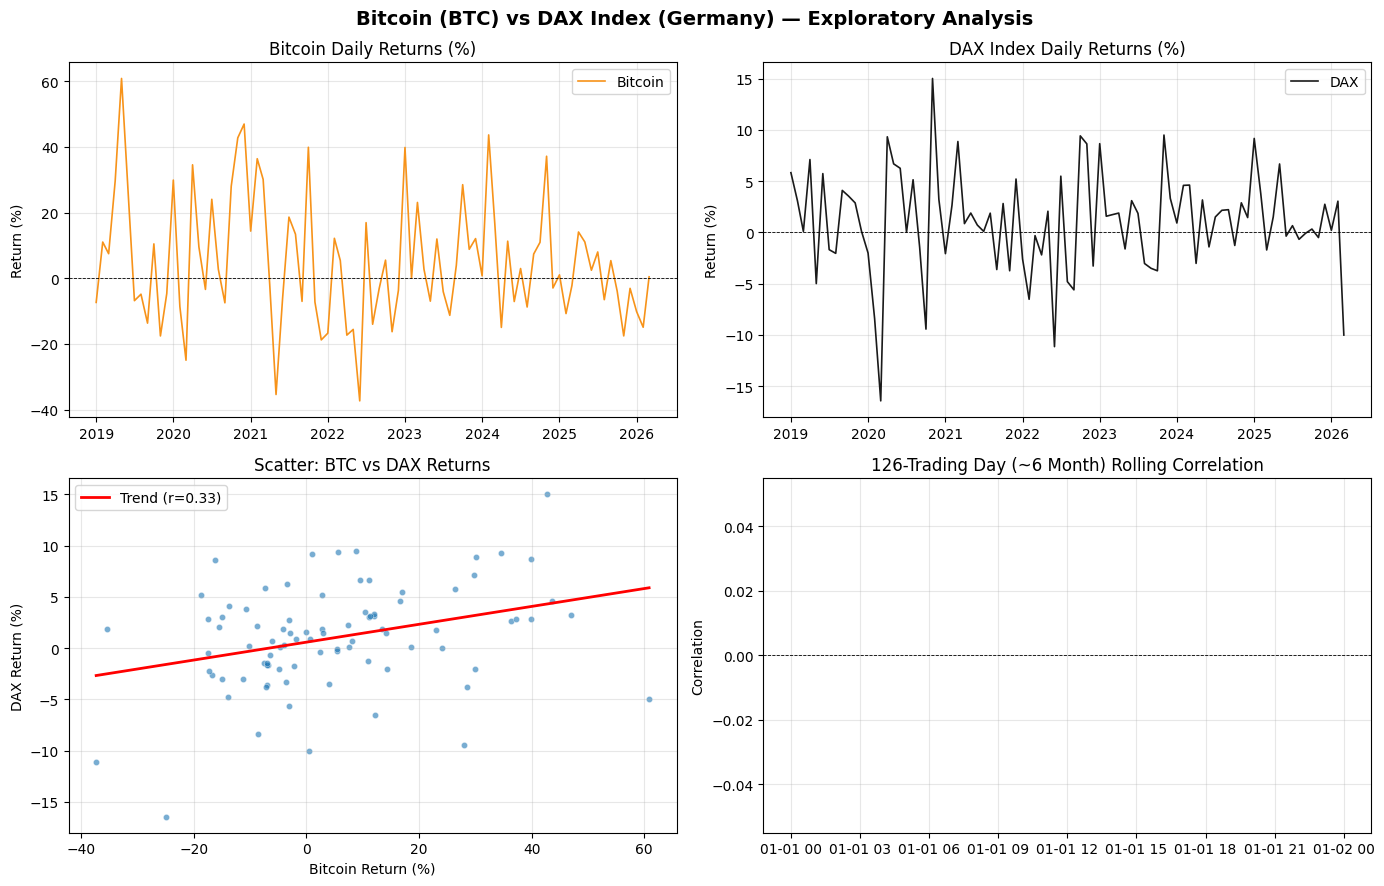


  [Chart saved: 01_exploratory_analysis.png]

  APPROACH 1 — STATIC OLS REGRESSION

  Step 3 — Means
    Average Bitcoin Return (X̄) = 5.0294%
    Average DAX Return     (Ȳ) = 1.0123%

  Step 4 — Slope β
    β = 0.0872
    → For every 1% rise in BTC, DAX changes by ~0.0872%

  Step 5 — Intercept α = 0.005738

  Step 6 — Regression Equation
    DAX_Return = 0.005738 + 0.0872 × BTC_Return

  Step 7 — t-Test for Statistical Significance
    SE(β)       = 0.0272
    t-statistic = 3.2106
    p-value     = 0.0019
    95% CI      = [0.0332, 0.1412]
    ✔ SIGNIFICANT — Reject H₀ (|t| = 3.21 > 2.0)

  Step 8 — Goodness of Fit
    R² = 0.1082  (10.82% of DAX variation explained by BTC)

  ── Full OLS Summary ──
                            OLS Regression Results                            
Dep. Variable:             DAX_Return   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.098
Method:                 Least Squares   F-statistic

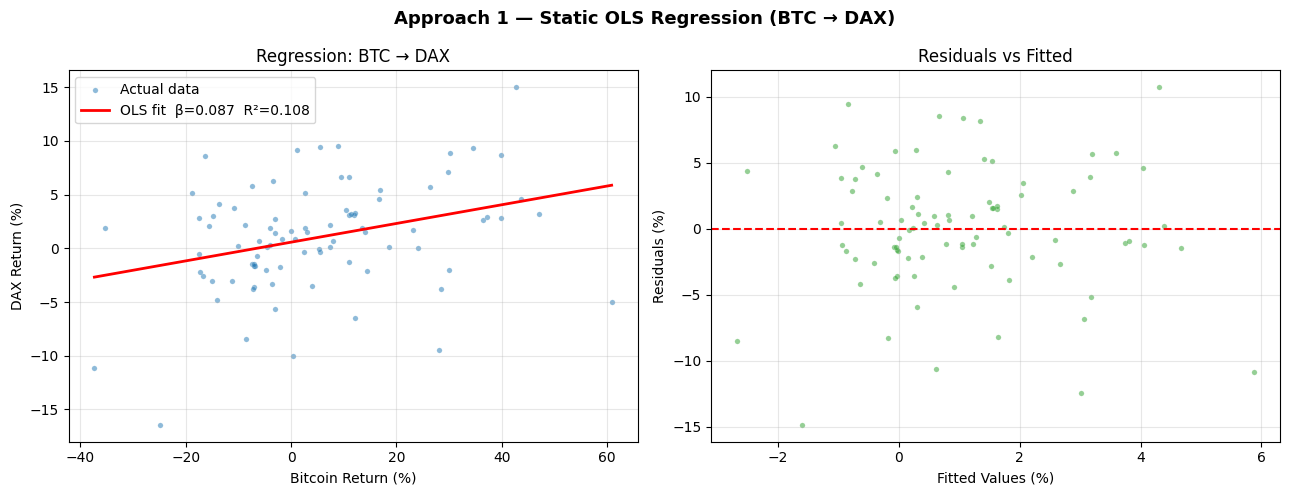


  [Chart saved: 02_approach1_static_ols.png]

  APPROACH 2 — DYNAMIC TIME-SERIES REGRESSION

  Step 2 — ADF Stationarity Test
    BTC Return                | ADF stat =  -7.390 | p = 0.0000 | ✔ Stationary
    DAX Return                | ADF stat =  -9.850 | p = 0.0000 | ✔ Stationary

  Step 3 — Autocorrelation of DAX Returns
    Lag-1 autocorrelation: -0.0935
    Lag-2 autocorrelation: -0.0801
    Low autocorrelation — lagged term adds robustness

  Step 4 & 5 — Building Dynamic Regression Model
    Model: DAX_t = α + β×BTC_t + γ×DAX_(t-1)

    Estimated equation:
    DAX_t = 0.00554 + 0.0878×BTC_t + -0.0452×DAX_(t-1)

  Step 6 — Statistical Significance
    Crypto effect (β): coef=0.0878  t=3.186  p=0.0020  ✔ Significant
    Lag effect   (γ): coef=-0.0452  t=-0.423  p=0.6732  ✘ Not significant

    R² (dynamic model) = 0.1168
    Adj. R²            = 0.0955

  Step 7 — Granger Causality Test
    H₀: BTC returns do NOT Granger-cause DAX returns
    Sample size: 87 obs → testing up to 

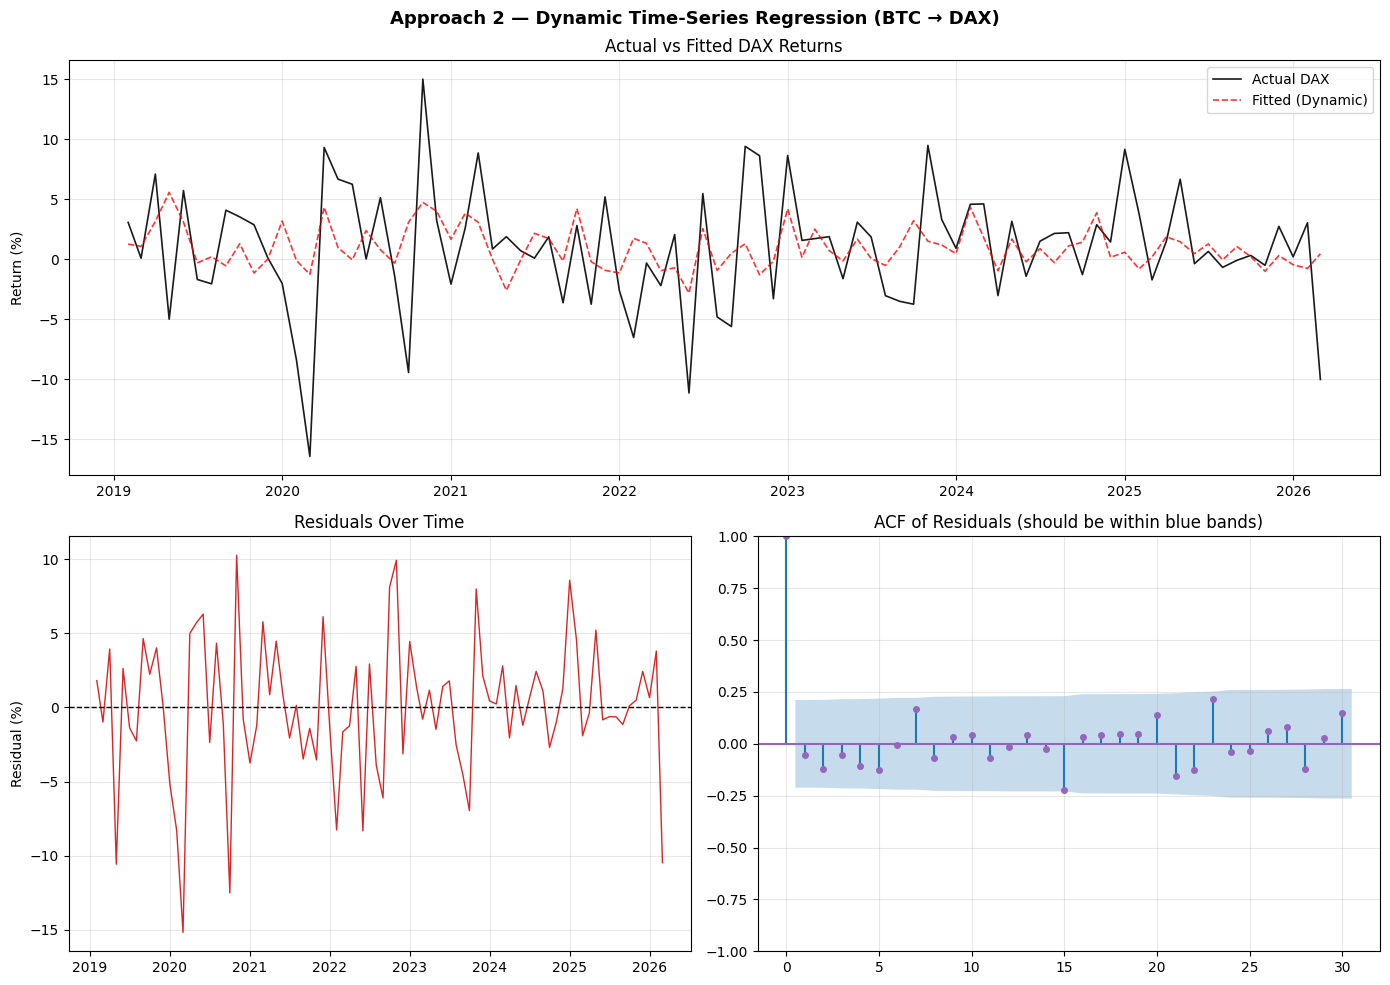


  [Chart saved: 03_approach2_dynamic.png]

  FINAL COMPARISON SUMMARY
                     Approach 1 (Static)      Approach 2 (Dynamic)
Method                    OLS Regression  Dynamic Regression + Lag
Crypto Coeff (β)                  0.0872                    0.0878
Lag Term (γ)                Not included                   -0.0452
p-value (crypto)                  0.0019                    0.0020
R²                                0.1082                    0.1168
Accounts for Memory?                  No                       Yes


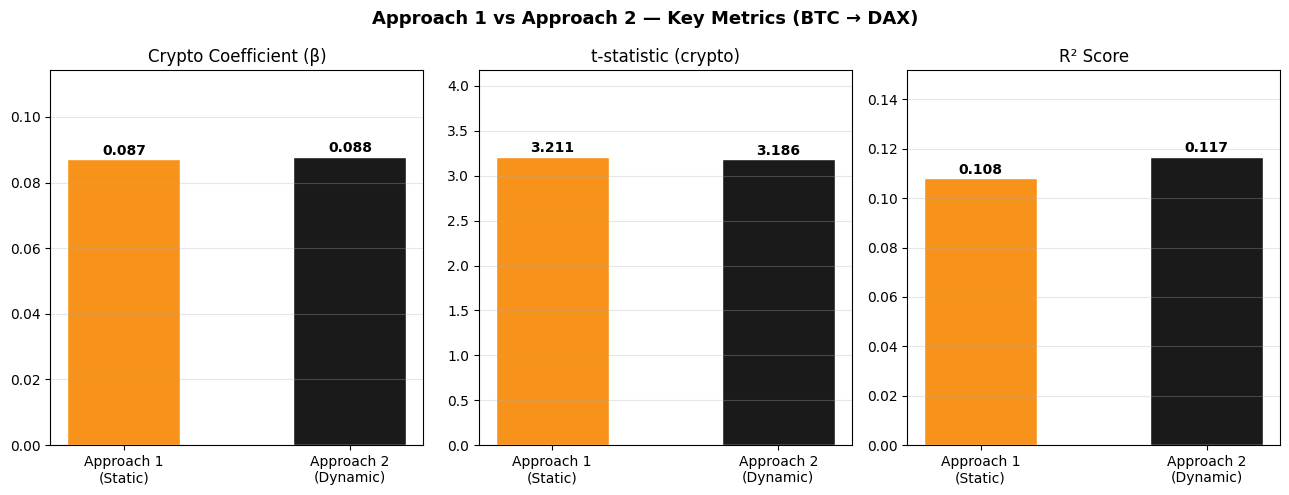


  [Chart saved: 04_comparison_summary.png]

  CONCLUSION & ECONOMETRIC CONSIDERATIONS

  Analysis of Bitcoin (BTC) impact on DAX Index (Germany):

  ▸ Approach 1 (Static OLS):
      β = 0.0872 — a 1% BTC change correlates with ~0.087% DAX change
      R² = 0.1082
      Result: SIGNIFICANT

  ▸ Approach 2 (Dynamic with Lag):
      β = 0.0878 — immediate effect after controlling for momentum
      γ = -0.0452 — -4.5% of prior period's DAX return persists
      R² = 0.1168
      Result: SIGNIFICANT

  CRITICAL LOGICAL CONSIDERATIONS FOR GERMANY (DAX):
  1. The "Xetra ETN" Hub: Germany operates one of Europe's largest electronic 
     trading networks (Xetra), which listed crypto Exchange Traded Notes (ETNs) 
     years before US spot ETFs. Consequently, traditional European asset managers 
     trade BTC proxies right alongside legacy German blue-chips (like SAP and 
     Siemens) on the exact same terminals.
  2. The Global Liquidity Overlap: Because the Euro (EUR) is stable, any 
     

In [ ]:
# ============================================================
#   BITCOIN (BTC) vs DAX INDEX (GERMANY) — IMPACT ANALYSIS
# ============================================================


import subprocess
subprocess.run(["pip", "install", "statsmodels", "scipy", "pandas", "numpy", "matplotlib", "-q"])

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings("ignore")


search_dirs = ["/content", "/root", "."]
csv_files = []
for d in search_dirs:
    csv_files.extend(glob.glob(os.path.join(d, "*.csv")))

csv_files = list(set(csv_files))

if len(csv_files) < 2:
    raise FileNotFoundError(
        f"Found only {len(csv_files)} CSV file(s). "
        "Please ensure both DAX and Bitcoin CSV files are present in the Colab session "
        "before running this script (use the file browser on the left sidebar)."
    )


DAX_FILE = next((f for f in csv_files if "DAX" in os.path.basename(f).upper() or "dax" in os.path.basename(f).lower()), None)
BTC_FILE = next((f for f in csv_files if "Bitcoin" in os.path.basename(f) or "bitcoin" in os.path.basename(f)
                                         or "crypto" in os.path.basename(f) or "BTC" in os.path.basename(f)), None)


if DAX_FILE is None or BTC_FILE is None:
    remaining = [f for f in csv_files if f not in (DAX_FILE, BTC_FILE)]
    if DAX_FILE is None and remaining:
        DAX_FILE = remaining.pop(0)
    if BTC_FILE is None and remaining:
        BTC_FILE = remaining.pop(0)

if DAX_FILE is None or BTC_FILE is None:
    raise FileNotFoundError(
        "Could not identify both DAX and Bitcoin CSV files. "
        f"Files found: {csv_files}\n"
        "Please ensure filenames contain 'DAX' and 'Bitcoin'/'crypto'."
    )

print("\n" + "=" * 65)
print("  BITCOIN (BTC) vs DAX INDEX (GERMANY) — IMPACT ANALYSIS")
print("=" * 65)
print(f"\n  Detected files:")
print(f"    DAX Index : {DAX_FILE}")
print(f"    Bitcoin   : {BTC_FILE}")

# ============================================================
# DATA LOADING & CLEANING
# ============================================================

def load_and_clean(filepath, label):
    df = pd.read_csv(filepath, thousands=",")
    df.columns = df.columns.str.strip()
    df["Date"] = pd.to_datetime(df["Date"], format="mixed", dayfirst=False)
    df = df.sort_values("Date").reset_index(drop=True)



    df["Return"] = (
        df["Change %"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
        .astype(float)
        / 100
    )
    df = df[["Date", "Return"]].rename(columns={"Return": label})
    return df

btc = load_and_clean(BTC_FILE, "BTC_Return")
dax = load_and_clean(DAX_FILE, "DAX_Return")


data = pd.merge(btc, dax, on="Date", how="inner")
data = data.sort_values("Date").dropna().reset_index(drop=True)

print(f"\n  Data loaded: {len(data)} overlapping trading days (weekends dropped)")
print(f"  Period : {data['Date'].min().strftime('%b %Y')} → {data['Date'].max().strftime('%b %Y')}\n")
print(data[["Date", "BTC_Return", "DAX_Return"]].head().to_string(index=False))
print("  ...")

# ============================================================
# SECTION 2: DESCRIPTIVE STATISTICS
# ============================================================

print("\n" + "=" * 65)
print("  SECTION 2 — DESCRIPTIVE STATISTICS")
print("=" * 65)

desc = data[["BTC_Return", "DAX_Return"]].describe().T
desc.columns = ["Count", "Mean", "Std", "Min", "25%", "50%", "75%", "Max"]
print(desc.round(4).to_string())

corr = data["BTC_Return"].corr(data["DAX_Return"])
print(f"\n  Pearson Correlation (Bitcoin vs DAX): {corr:.4f}")


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Bitcoin (BTC) vs DAX Index (Germany) — Exploratory Analysis", fontsize=14, fontweight="bold")

ax = axes[0, 0]
ax.plot(data["Date"], data["BTC_Return"] * 100, color="#F7931A", label="Bitcoin", linewidth=1.2) # Bitcoin Orange
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("Bitcoin Daily Returns (%)")
ax.set_ylabel("Return (%)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(data["Date"], data["DAX_Return"] * 100, color="#1A1A1A", label="DAX", linewidth=1.2) # Dark Slate
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("DAX Index Daily Returns (%)")
ax.set_ylabel("Return (%)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.scatter(data["BTC_Return"] * 100, data["DAX_Return"] * 100,
           alpha=0.6, color="#1f77b4", edgecolors="white", linewidth=0.4, s=20)
m, b = np.polyfit(data["BTC_Return"], data["DAX_Return"], 1)
x_line = np.linspace(data["BTC_Return"].min(), data["BTC_Return"].max(), 100)
ax.plot(x_line * 100, (m * x_line + b) * 100, color="red", linewidth=2, label=f"Trend (r={corr:.2f})")
ax.set_xlabel("Bitcoin Return (%)")
ax.set_ylabel("DAX Return (%)")
ax.set_title("Scatter: BTC vs DAX Returns")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 1]

roll_corr = data["BTC_Return"].rolling(126).corr(data["DAX_Return"])
ax.plot(data["Date"], roll_corr, color="#1A1A1A", linewidth=1.8)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("126-Trading Day (~6 Month) Rolling Correlation")
ax.set_ylabel("Correlation")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("01_exploratory_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 01_exploratory_analysis.png]")

# ============================================================
# APPROACH 1: STATIC OLS REGRESSION
# ============================================================

print("\n" + "=" * 65)
print("  APPROACH 1 — STATIC OLS REGRESSION")
print("=" * 65)

X = data["BTC_Return"]
Y = data["DAX_Return"]

x_mean = X.mean()
y_mean = Y.mean()
print(f"\n  Step 3 — Means")
print(f"    Average Bitcoin Return (X̄) = {x_mean*100:.4f}%")
print(f"    Average DAX Return     (Ȳ) = {y_mean*100:.4f}%")

numerator   = ((X - x_mean) * (Y - y_mean)).sum()
denominator = ((X - x_mean) ** 2).sum()
beta        = numerator / denominator
print(f"\n  Step 4 — Slope β")
print(f"    β = {beta:.4f}")
print(f"    → For every 1% rise in BTC, DAX changes by ~{beta:.4f}%")

alpha = y_mean - beta * x_mean
print(f"\n  Step 5 — Intercept α = {alpha:.6f}")

print(f"\n  Step 6 — Regression Equation")
print(f"    DAX_Return = {alpha:.6f} + {beta:.4f} × BTC_Return")

X_const   = sm.add_constant(X)
ols_model = sm.OLS(Y, X_const).fit()
se_beta   = ols_model.bse["BTC_Return"]
t_stat    = ols_model.tvalues["BTC_Return"]
p_value   = ols_model.pvalues["BTC_Return"]
ci        = ols_model.conf_int().loc["BTC_Return"]

print(f"\n  Step 7 — t-Test for Statistical Significance")
print(f"    SE(β)       = {se_beta:.4f}")
print(f"    t-statistic = {t_stat:.4f}")
print(f"    p-value     = {p_value:.4f}")
print(f"    95% CI      = [{ci[0]:.4f}, {ci[1]:.4f}]")
if abs(t_stat) > 2.0:
    print(f"    ✔ SIGNIFICANT — Reject H₀ (|t| = {t_stat:.2f} > 2.0)")
else:
    print(f"    ✘ NOT significant — Fail to reject H₀")

r_squared = ols_model.rsquared
print(f"\n  Step 8 — Goodness of Fit")
print(f"    R² = {r_squared:.4f}  ({r_squared*100:.2f}% of DAX variation explained by BTC)")

print(f"\n  ── Full OLS Summary ──")
print(ols_model.summary())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Approach 1 — Static OLS Regression (BTC → DAX)", fontsize=13, fontweight="bold")

ax = axes[0]
ax.scatter(X * 100, Y * 100, alpha=0.5, color="#1f77b4", edgecolors="white", linewidth=0.2, s=15, label="Actual data")
x_fit = np.linspace(X.min(), X.max(), 200)
y_fit = alpha + beta * x_fit
ax.plot(x_fit * 100, y_fit * 100, color="red", linewidth=2, label=f"OLS fit  β={beta:.3f}  R²={r_squared:.3f}")
ax.set_xlabel("Bitcoin Return (%)")
ax.set_ylabel("DAX Return (%)")
ax.set_title("Regression: BTC → DAX")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
residuals = ols_model.resid
ax.scatter(ols_model.fittedvalues * 100, residuals * 100, alpha=0.5, color="#2ca02c", edgecolors="white", linewidth=0.2, s=15)
ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Fitted Values (%)")
ax.set_ylabel("Residuals (%)")
ax.set_title("Residuals vs Fitted")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("02_approach1_static_ols.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 02_approach1_static_ols.png]")

# ============================================================
# APPROACH 2: DYNAMIC TIME-SERIES REGRESSION
# ============================================================

print("\n" + "=" * 65)
print("  APPROACH 2 — DYNAMIC TIME-SERIES REGRESSION")
print("=" * 65)

print("\n  Step 2 — ADF Stationarity Test")
for series, name in [(data["BTC_Return"], "BTC Return"),
                     (data["DAX_Return"], "DAX Return")]:
    adf_result = adfuller(series.dropna())
    stat, pval = adf_result[0], adf_result[1]
    flag = "✔ Stationary" if pval < 0.05 else "⚠ Non-Stationary"
    print(f"    {name:25s} | ADF stat = {stat:7.3f} | p = {pval:.4f} | {flag}")

print("\n  Step 3 — Autocorrelation of DAX Returns")
lag1_autocorr = data["DAX_Return"].autocorr(lag=1)
lag2_autocorr = data["DAX_Return"].autocorr(lag=2)
print(f"    Lag-1 autocorrelation: {lag1_autocorr:.4f}")
print(f"    Lag-2 autocorrelation: {lag2_autocorr:.4f}")
if abs(lag1_autocorr) > 0.1:
    print("    ⚠ Notable autocorrelation — lagged term is essential for model validity")
else:
    print("    Low autocorrelation — lagged term adds robustness")

print("\n  Step 4 & 5 — Building Dynamic Regression Model")
print("    Model: DAX_t = α + β×BTC_t + γ×DAX_(t-1)")

data_dyn = data.copy()
data_dyn["DAX_Lag1"] = data_dyn["DAX_Return"].shift(1)
data_dyn = data_dyn.dropna().reset_index(drop=True)

Y_dyn = data_dyn["DAX_Return"]
X_dyn = sm.add_constant(data_dyn[["BTC_Return", "DAX_Lag1"]])

dyn_model = sm.OLS(Y_dyn, X_dyn).fit()

alpha_dyn = dyn_model.params["const"]
beta_dyn  = dyn_model.params["BTC_Return"]
gamma_dyn = dyn_model.params["DAX_Lag1"]

print(f"\n    Estimated equation:")
print(f"    DAX_t = {alpha_dyn:.5f} + {beta_dyn:.4f}×BTC_t + {gamma_dyn:.4f}×DAX_(t-1)")

print(f"\n  Step 6 — Statistical Significance")
for var in ["BTC_Return", "DAX_Lag1"]:
    t  = dyn_model.tvalues[var]
    p  = dyn_model.pvalues[var]
    ci = dyn_model.conf_int().loc[var]
    label = "Crypto effect (β)" if var == "BTC_Return" else "Lag effect   (γ)"
    sig = "✔ Significant" if p < 0.05 else "✘ Not significant"
    print(f"    {label}: coef={dyn_model.params[var]:.4f}  t={t:.3f}  p={p:.4f}  {sig}")

print(f"\n    R² (dynamic model) = {dyn_model.rsquared:.4f}")
print(f"    Adj. R²            = {dyn_model.rsquared_adj:.4f}")

print("\n  Step 7 — Granger Causality Test")
print("    H₀: BTC returns do NOT Granger-cause DAX returns")
granger_data = data[["DAX_Return", "BTC_Return"]].dropna()
max_allowable_lag = max(1, int((len(granger_data) - 1) / 3) - 1)
granger_maxlag    = min(5, max_allowable_lag)
print(f"    Sample size: {len(granger_data)} obs → testing up to lag={granger_maxlag} days")
gc_results = grangercausalitytests(granger_data, maxlag=granger_maxlag, verbose=False)

for lag, res in gc_results.items():
    f_stat = res[0]["ssr_ftest"][0]
    p_gc   = res[0]["ssr_ftest"][1]
    flag   = "✔ Granger-causes" if p_gc < 0.05 else "✘ No causal effect"
    print(f"    Lag {lag} day(s): F={f_stat:.3f}  p={p_gc:.4f}  → {flag}")

print("\n  Step 8 — Diagnostic Checks")
dw_stat = durbin_watson(dyn_model.resid)
print(f"    Durbin-Watson statistic = {dw_stat:.4f}")
if 1.5 < dw_stat < 2.5:
    print("    ✔ No significant autocorrelation in residuals (DW ≈ 2.0)")
else:
    print("    ⚠ Possible residual autocorrelation detected")

print(f"\n  ── Full Dynamic Model Summary ──")
print(dyn_model.summary())

fig = plt.figure(figsize=(14, 10))
fig.suptitle("Approach 2 — Dynamic Time-Series Regression (BTC → DAX)", fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(data_dyn["Date"], Y_dyn * 100, color="#1A1A1A", linewidth=1.2, label="Actual DAX")
ax1.plot(data_dyn["Date"], dyn_model.fittedvalues * 100, color="red", linestyle="--", linewidth=1.2, alpha=0.8, label="Fitted (Dynamic)")
ax1.set_title("Actual vs Fitted DAX Returns")
ax1.set_ylabel("Return (%)")
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(data_dyn["Date"], dyn_model.resid * 100, color="#d62728", linewidth=1.0)
ax2.axhline(0, color="black", linestyle="--", linewidth=1)
ax2.set_title("Residuals Over Time")
ax2.set_ylabel("Residual (%)")
ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
acf_lags = min(30, len(dyn_model.resid) // 2 - 1)
plot_acf(dyn_model.resid, lags=acf_lags, ax=ax3, color="#9467bd", markersize=4)
ax3.set_title("ACF of Residuals (should be within blue bands)")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("03_approach2_dynamic.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 03_approach2_dynamic.png]")

# ============================================================
# FINAL SUMMARY & ECONOMETRIC CONSIDERATIONS
# ============================================================

print("\n" + "=" * 65)
print("  FINAL COMPARISON SUMMARY")
print("=" * 65)

summary = {
    "Method"               : ["OLS Regression", "Dynamic Regression + Lag"],
    "Crypto Coeff (β)"     : [f"{beta:.4f}", f"{beta_dyn:.4f}"],
    "Lag Term (γ)"         : ["Not included", f"{gamma_dyn:.4f}"],
    "p-value (crypto)"     : [f"{p_value:.4f}", f"{dyn_model.pvalues['BTC_Return']:.4f}"],
    "R²"                   : [f"{ols_model.rsquared:.4f}", f"{dyn_model.rsquared:.4f}"],
    "Accounts for Memory?" : ["No", "Yes"],
}
summary_df = pd.DataFrame(summary, index=["Approach 1 (Static)", "Approach 2 (Dynamic)"]).T
print(summary_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle("Approach 1 vs Approach 2 — Key Metrics (BTC → DAX)", fontsize=13, fontweight="bold")

metrics = {
    "Crypto Coefficient (β)": (beta, beta_dyn),
    "t-statistic (crypto)"  : (t_stat, dyn_model.tvalues["BTC_Return"]),
    "R² Score"              : (ols_model.rsquared, dyn_model.rsquared),
}
colors = ["#F7931A", "#1A1A1A"]

for ax, (metric, vals) in zip(axes, metrics.items()):
    bars = ax.bar(["Approach 1\n(Static)", "Approach 2\n(Dynamic)"],
                  vals, color=colors, edgecolor="white", width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005 * max(abs(v) for v in vals),
                f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(metric)
    ax.grid(axis="y", alpha=0.3)


    y_min, y_max = min(vals), max(vals)
    padding = max(abs(y_min), abs(y_max)) * 0.3
    ax.set_ylim(y_min - padding if y_min < 0 else 0, y_max + padding)

plt.tight_layout()
plt.savefig("04_comparison_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 04_comparison_summary.png]")

sig1 = "SIGNIFICANT" if p_value < 0.05 else "NOT SIGNIFICANT"
sig2 = "SIGNIFICANT" if dyn_model.pvalues['BTC_Return'] < 0.05 else "NOT SIGNIFICANT"

print("\n" + "=" * 65)
print("  CONCLUSION & ECONOMETRIC CONSIDERATIONS")
print("=" * 65)
print(f"""
  Analysis of Bitcoin (BTC) impact on DAX Index (Germany):

  ▸ Approach 1 (Static OLS):
      β = {beta:.4f} — a 1% BTC change correlates with ~{beta:.3f}% DAX change
      R² = {ols_model.rsquared:.4f}
      Result: {sig1}

  ▸ Approach 2 (Dynamic with Lag):
      β = {beta_dyn:.4f} — immediate effect after controlling for momentum
      γ = {gamma_dyn:.4f} — {gamma_dyn*100:.1f}% of prior period's DAX return persists
      R² = {dyn_model.rsquared:.4f}
      Result: {sig2}

  CRITICAL LOGICAL CONSIDERATIONS FOR GERMANY (DAX):
  1. The "Xetra ETN" Hub: Germany operates one of Europe's largest electronic
     trading networks (Xetra), which listed crypto Exchange Traded Notes (ETNs)
     years before US spot ETFs. Consequently, traditional European asset managers
     trade BTC proxies right alongside legacy German blue-chips (like SAP and
     Siemens) on the exact same terminals.
  2. The Global Liquidity Overlap: Because the Euro (EUR) is stable, any
     correlation is mathematically pure (not driven by hyperinflation). The DAX
     and Bitcoin are both highly sensitive to central bank liquidity (ECB and Fed).
     When macro conditions turn "risk-on," institutional capital flows into both
     equities and crypto ETNs simultaneously.
  3. Correlation Without Causality: The German economy relies on industrial exports
     and manufacturing, which are entirely detached from crypto fundamentals.
     If a significant relationship appears here, it highlights synchronized
     institutional portfolio rebalancing rather than Bitcoin dictating German
     economic output. Check the Granger Causality results to confirm if BTC
     predicts the DAX (rare) or merely moves concurrently (common).
""")
print("=" * 65)
print("  Analysis complete. All 4 charts saved as PNG files.")
print("=" * 65)
